In [1]:
# 06 - K-Means Clustering on Amazon Customer Dataset

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [3]:
data = pd.read_csv('datasets/Amazon_com_Clusturing_Model.csv')
print("Shape:", data.shape)
print(data.head(10))
print()
print(data.describe())

Shape: (200, 5)
   Cus_ID Sex  Age   Income  Rating
0  301219   M   37   581052      96
1  301220   F   25   288994      36
2  301221   F   38   492702      34
3  301222   M   36   734878      46
4  301223   F   31   318271      44
5  301224   M   60  1826710      64
6  301225   F   23   254669      53
7  301226   M   25   511166      85
8  301227   F   31   722308      31
9  301228   F   48  2453041      63

              Cus_ID         Age        Income      Rating
count     200.000000  200.000000  2.000000e+02  200.000000
mean   301318.500000   33.945000  7.806506e+05   56.320000
std        57.879185   10.181369  4.957218e+05   22.532112
min    301219.000000   19.000000  2.325070e+05    1.000000
25%    301268.750000   26.000000  3.859498e+05   38.750000
50%    301318.500000   31.000000  6.380670e+05   54.000000
75%    301368.250000   40.000000  8.459250e+05   74.000000
max    301418.000000   65.000000  2.453041e+06   98.000000


In [4]:
print("Sex distribution:")
print(data['Sex'].value_counts())

Sex distribution:
Sex
F    110
M     90
Name: count, dtype: int64


In [5]:
print("Null values:")
print(data.isnull().sum())

Null values:
Cus_ID    0
Sex       0
Age       0
Income    0
Rating    0
dtype: int64


In [6]:
# Select Age (col 2) and Rating (col 4) for clustering

In [7]:
X = data.iloc[:, [2, 4]].values
print("X shape:", X.shape)
print("First 5 rows (Age, Rating):")
print(X[:5])

X shape: (200, 2)
First 5 rows (Age, Rating):
[[37 96]
 [25 36]
 [38 34]
 [36 46]
 [31 44]]


In [8]:
sc = StandardScaler()
X_scaled = sc.fit_transform(X)
print("Standardised.")

Standardised.


In [9]:
# Elbow Method to find optimal K

In [10]:
wcss = []
for k in range(1, 11):
    model = KMeans(n_clusters=k, init='k-means++', random_state=21, n_init=10)
    model.fit(X_scaled)
    wcss.append(model.inertia_)

print("WCSS by K:")
for k, w in enumerate(wcss, 1):
    print("  K =", k, " WCSS =", round(w, 2))

WCSS by K:
  K = 1  WCSS = 400.0
  K = 2  WCSS = 231.08
  K = 3  WCSS = 101.95
  K = 4  WCSS = 75.65
  K = 5  WCSS = 60.67
  K = 6  WCSS = 51.16
  K = 7  WCSS = 42.83
  K = 8  WCSS = 37.4
  K = 9  WCSS = 33.4
  K = 10  WCSS = 30.18


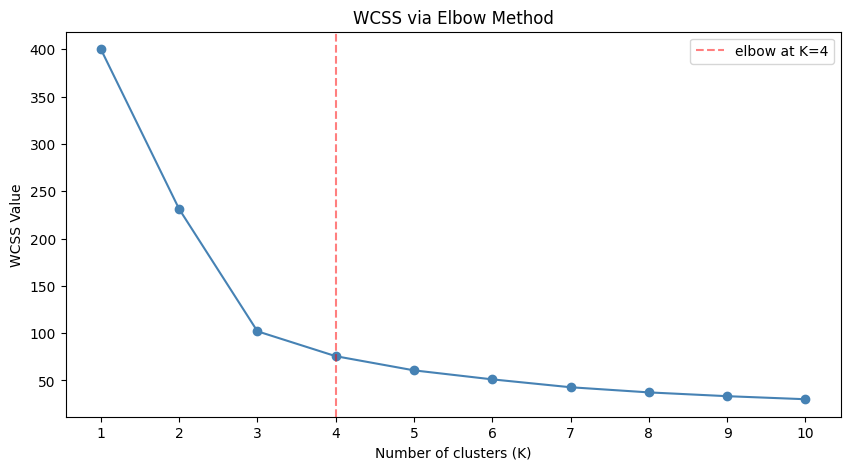

In [11]:
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, 'o-', color='steelblue')
plt.axvline(4, color='red', linestyle='--', alpha=0.5, label='elbow at K=4')
plt.title('WCSS via Elbow Method')
plt.xlabel('Number of clusters (K)')
plt.ylabel('WCSS Value')
plt.xticks(range(1, 11))
plt.legend()
plt.show()

In [12]:
# Train K-Means with K = 4

In [13]:
model = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
y_means = model.fit_predict(X_scaled)

print("Cluster labels (first 40):")
print(y_means[:40])
print()
print("Cluster sizes:", dict(zip(*np.unique(y_means, return_counts=True))))
print()
print("Centroids (scaled):")
print(model.cluster_centers_)

Cluster labels (first 40):
[3 1 2 1 1 0 1 3 2 0 3 1 3 2 0 1 3 3 1 3 1 2 3 0 0 2 3 3 0 3 2 1 3 2 3 3 0
 1 2 0]

Cluster sizes: {np.int32(0): np.int64(49), np.int32(1): np.int64(58), np.int32(2): np.int64(36), np.int32(3): np.int64(57)}

Centroids (scaled):
[[ 1.4864109   0.06839129]
 [-0.64309587 -0.44995699]
 [ 0.07105897 -1.34777591]
 [-0.66829292  1.25028535]]


In [14]:
# Plot the clusters

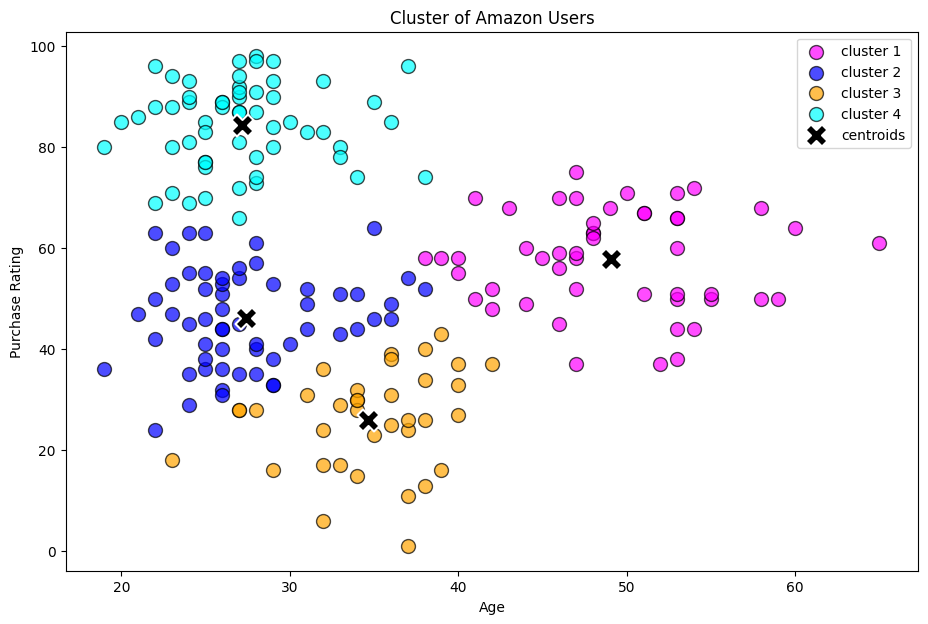

In [15]:
centroids = sc.inverse_transform(model.cluster_centers_)
X_orig = X

plt.figure(figsize=(11, 7))
colors = ['magenta', 'blue', 'orange', 'cyan']
for c in range(4):
    plt.scatter(X_orig[y_means == c, 0], X_orig[y_means == c, 1],
                s=100, c=colors[c], label='cluster ' + str(c+1),
                edgecolors='k', alpha=0.7)
plt.scatter(centroids[:, 0], centroids[:, 1],
            s=250, c='black', marker='X', label='centroids',
            edgecolors='white', linewidths=1.5)

plt.title('Cluster of Amazon Users')
plt.xlabel('Age')
plt.ylabel('Purchase Rating')
plt.legend()
plt.show()

In [16]:
# Silhouette Score for validation

Silhouette score for K=4: 0.4716


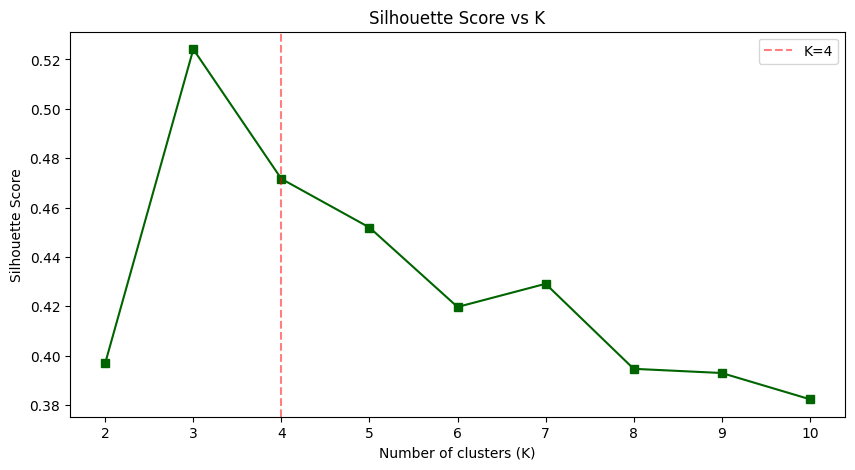

In [17]:
sil = silhouette_score(X_scaled, y_means)
print("Silhouette score for K=4:", round(sil, 4))

sil_scores = []
for k in range(2, 11):
    m = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    labels = m.fit_predict(X_scaled)
    sil_scores.append(silhouette_score(X_scaled, labels))

plt.figure(figsize=(10, 5))
plt.plot(range(2, 11), sil_scores, 's-', color='darkgreen')
plt.axvline(4, color='red', linestyle='--', alpha=0.5, label='K=4')
plt.title('Silhouette Score vs K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Silhouette Score')
plt.xticks(range(2, 11))
plt.legend()
plt.show()

In [18]:
# Cluster Profiles

         n_customers  mean_age  mean_income  mean_rating
Cluster                                                 
0                 49     49.04   1487788.51        57.86
1                 58     27.41    439902.53        46.21
2                 36     34.67    701627.67        26.03
3                 57     27.16    569395.40        84.42


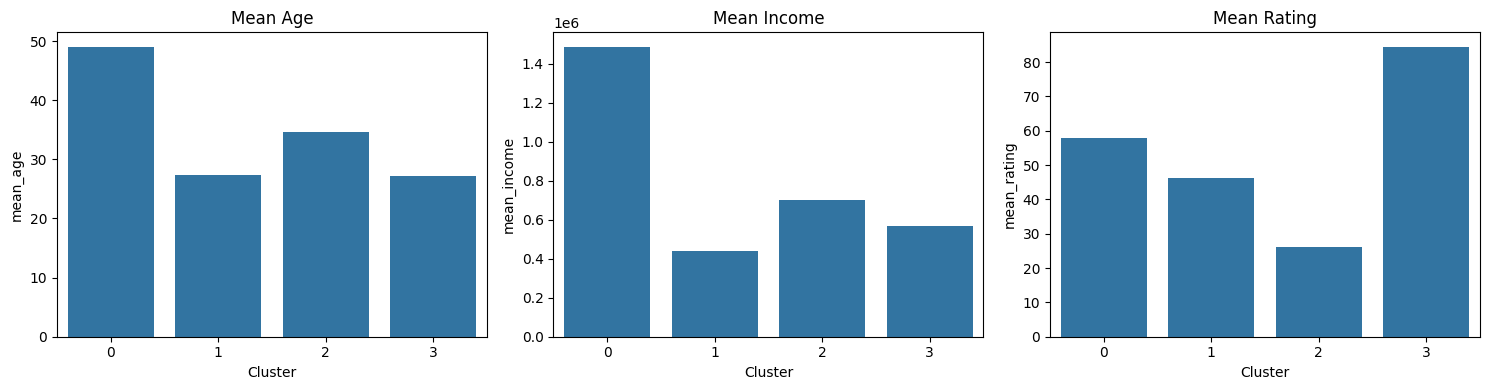

In [19]:
data['Cluster'] = y_means
profile = data.groupby('Cluster').agg(
    n_customers=('Cus_ID', 'count'),
    mean_age=('Age', 'mean'),
    mean_income=('Income', 'mean'),
    mean_rating=('Rating', 'mean'),
).round(2)
print(profile)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col, title in zip(axes,
                         ['mean_age', 'mean_income', 'mean_rating'],
                         ['Mean Age', 'Mean Income', 'Mean Rating']):
    sns.barplot(x=profile.index, y=profile[col], ax=ax)
    ax.set_title(title)
    ax.set_xlabel('Cluster')
plt.tight_layout()
plt.show()